# 04 — Model Training

Audit labels, split integrity, and image quality before training. Every suspicious image stays in the dataset unless a separate, reviewed ruling removes it. Validation uses held-out filename groups; these are not verified writer identities. Because validation selects settings, its best score is optimistic.

Run sections in order. Raw images belong under data/baseline/raw. Pretrained ImageNet weights download on first use. The notebook checks exact class indexing, Unicode identity, and the TIS-620 mapping. Visual confirmation of each class remains a separate review task in 02_visual_check.py.

## 1. Configuration

Set compute and experiment budgets here. Screening phases use five epochs; final runs use 15. Results are cached by exact split membership, configuration, and implementation.

In [14]:
import hashlib
import json
import sys
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib import font_manager
from PIL import Image
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

project_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
ROOT = next((path for path in project_roots
             if (path / 'pyproject.toml').is_file() and (path / 'src' / 'thai_char_cnn').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the thai-char-cnn project directory or one of its subdirectories.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from thai_char_cnn.cv_experiments import Experiment, GlyphDataset, build_backbone, run_experiment, secure_split
from thai_char_cnn.paths import CONFIGS, FONT, RAW, ROOT, RUNS, SPLIT_DIR
from thai_char_cnn.quality import QUALITY_VERSION, audit_images, count_cleaned_images, flag_quality, preprocess_candidate

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
SCREEN_EPOCHS = 5
FINAL_EPOCHS = 15
WORKERS = 0  # Safe in a notebook on macOS; increase on Linux when useful.
DATASET_PATH = RAW.resolve()
quality_code = (ROOT / 'src' / 'thai_char_cnn' / 'quality.py').read_bytes()
quality_code_hash = hashlib.sha256(quality_code).hexdigest()[:8]
QUALITY_CSV = RAW.parent / 'quality' / f'quality_v{QUALITY_VERSION}_{quality_code_hash}.csv'
RUN_ROOT = RUNS / 'quality_cv'
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
font_manager.fontManager.addfont(str(FONT))
THAI = font_manager.FontProperties(fname=str(FONT), size=13)
pd.set_option('display.max_columns', 30)
print('TRAINING CONFIG')
for key, value in [('Device', DEVICE), ('Seed', SEED), ('Image Size', IMAGE_SIZE),
                   ('Batch Size', BATCH_SIZE), ('Target Classes', 72), ('Dataset Path', DATASET_PATH),
                   ('Screen Epochs', SCREEN_EPOCHS), ('Final Epochs', FINAL_EPOCHS)]:
    print(f'{key:18}: {value}')
if not RAW.exists() or not any(RAW.rglob('*.jpg')):
    raise FileNotFoundError(f'No raw images at {RAW}. Place the dataset there or link an existing local copy.')

TRAINING CONFIG
Device            : mps
Seed              : 42
Image Size        : 224
Batch Size        : 32
Target Classes    : 72
Dataset Path      : /Users/iam.pxk/Desktop/Thai_Word_404/Thai_word
Screen Epochs     : 5
Final Epochs      : 15


## 2. Dataset Integrity

Check exact class indexing, Unicode identity, file presence, and label review status. Unicode normalization is reported, never used to merge labels automatically.

In [15]:
images = pd.read_csv(SPLIT_DIR / 'images.csv', keep_default_na=False)
manifest = pd.read_csv(RAW.parent / 'manifest' / 'images.csv', keep_default_na=False)
classes = pd.read_csv(SPLIT_DIR / 'classes.csv', keep_default_na=False).sort_values('class_idx')
labels = pd.read_csv(CONFIGS / 'class_labels.csv', keep_default_na=False)
split_run = json.loads((SPLIT_DIR / 'run.json').read_text())
failed_checks = [name for name, status in split_run['checks'].items() if status != 'PASS']
assert not failed_checks, f'Split checks failed: {failed_checks}'
assert len(classes) == 72 and classes.class_idx.tolist() == list(range(72))
assert classes.character.nunique() == 72 and classes.folder.nunique() == 72
assert images.class_idx.isin(classes.class_idx).all()
assert images.path.is_unique
assert set(images.path) == set(manifest.path), 'Split and manifest paths differ.'
missing_files = [path for path in images.path if not (RAW / path).is_file()]
hashes = {path: hashlib.sha256((RAW / path).read_bytes()).hexdigest() if (RAW / path).is_file() else 'MISSING'
          for path in tqdm(images.path, desc='Verify raw image hashes')}
expected_hashes = manifest.set_index('path').sha256
hash_mismatches = [path for path, digest in hashes.items() if digest != 'MISSING' and digest != expected_hashes[path]]
assert not hash_mismatches, f'Raw files differ from audited manifest: {hash_mismatches[:5]}'
class_to_idx = dict(zip(classes.character, classes.class_idx, strict=True))
assert len(class_to_idx) == 72 and len(set(class_to_idx.keys())) == 72
audit_labels = classes[['class_idx', 'folder', 'character']].rename(columns={'character': 'label'})
audit_labels = audit_labels.merge(labels[['class_folder', 'character', 'confidence', 'note']],
                                  left_on='folder', right_on='class_folder', validate='one_to_one')
assert audit_labels.label.eq(audit_labels.character).all(), 'Split labels differ from configs/class_labels.csv.'
audit_labels['repr_label'] = audit_labels.label.map(repr)
audit_labels['unicode_codepoints'] = audit_labels.label.map(
    lambda s: ' '.join(f'U+{ord(ch):04X}' for ch in s))
audit_labels['tis620_matches'] = audit_labels.apply(
    lambda row: bytes([int(row.folder)]).decode('tis-620') == row.label, axis=1)
audit_labels['count'] = audit_labels.folder.map(images.groupby('label_class').size()).fillna(0).astype(int)
audit_labels['normalization_differs'] = audit_labels.label.map(lambda s: unicodedata.normalize('NFC', s) != s)
audit_labels['outer_whitespace'] = audit_labels.label.map(lambda s: s != s.strip())
audit_labels['reviewed'] = audit_labels.confidence.astype(str).str.strip().ne('') & ~audit_labels.note.str.contains('hypothesis', case=False, na=False)
assert not audit_labels.normalization_differs.any(), 'Review Unicode normalization differences.'
assert not audit_labels.outer_whitespace.any(), 'Review whitespace in labels.'
print('DATASET SUMMARY')
print(f'Total Images        : {len(images):,}')
print(f'Total Classes       : {len(classes)}')
print(f'Total Filename Groups: {images.writer_id.nunique()}')
print(f'Smallest Class      : {audit_labels.loc[audit_labels["count"].idxmin(), "label"]} ({audit_labels["count"].min():,})')
print(f'Largest Class       : {audit_labels.loc[audit_labels["count"].idxmax(), "label"]} ({audit_labels["count"].max():,})')
print(f'Median Class Size   : {audit_labels["count"].median():.0f}')
print(f'Labels Confirmed    : {audit_labels.reviewed.sum()} / 72')
print(f'TIS-620 Mappings    : {audit_labels.tis620_matches.sum()} / 72 match configured labels')
print(f'Raw SHA-256 Matches : {len(images) - len(missing_files):,} / {len(images):,}')
print(f'Missing Raw Images  : {len(missing_files):,} (excluded from model data; retained in quality report)')
if missing_files:
    display(images[images.path.isin(missing_files)][['path', 'writer_id', 'class_idx', 'split']])
display(audit_labels[['class_idx', 'label', 'repr_label', 'unicode_codepoints', 'count', 'tis620_matches', 'reviewed']])

Verify raw image hashes:   0%|          | 0/62707 [00:00<?, ?it/s]

DATASET SUMMARY
Total Images        : 62,707
Total Classes       : 72
Total Filename Groups: 52
Smallest Class      : ฃ (1)
Largest Class       : า (5,018)
Median Class Size   : 221
Labels Confirmed    : 0 / 72
TIS-620 Mappings    : 72 / 72 match configured labels
Raw SHA-256 Matches : 62,704 / 62,707
Missing Raw Images  : 3 (excluded from model data; retained in quality report)


,path,writer_id,class_idx,split
3,161/bc_001sg_3_32.jpg,bc_001,0,val
59925,230/bc_002tg_8_97.jpg,bc_002,56,train
62623,244/be_008tg_7_263.jpg,be_008,66,train


,class_idx,label,repr_label,unicode_codepoints,count,tis620_matches,reviewed
0,0,ก,'ก',U+0E01,1951,True,False
1,1,ข,'ข',U+0E02,1355,True,False
2,2,ฃ,'ฃ',U+0E03,1,True,False
3,3,ค,'ค',U+0E04,1449,True,False
4,4,ง,'ง',U+0E07,1078,True,False
...,...,...,...,...,...,...,...
67,67,๕,'๕',U+0E55,17,True,False
68,68,๖,'๖',U+0E56,12,True,False
69,69,๗,'๗',U+0E57,4,True,False
70,70,๘,'๘',U+0E58,27,True,False


## 3. Writer Analysis

The supplied split moves 27 tiny-class images into training from validation groups and shares exact image hashes across sides. The effective split removes conflicting training rows while preserving validation membership.

In [16]:
effective, split_info = secure_split(images[~images.path.isin(missing_files)], manifest)
train_rows = effective[effective.split == 'train']
val_rows = effective[effective.split == 'val']
assert set(train_rows.writer_id).isdisjoint(val_rows.writer_id)
assert set(train_rows.sha_group_id).isdisjoint(val_rows.sha_group_id)
assert set(train_rows.near_dup_group_id).isdisjoint(val_rows.near_dup_group_id)
print('WRITER-LEVEL SPLIT')
for key, value in [('Train Images', split_info['train']), ('Validation Images', split_info['val']),
                   ('Train Filename Groups', split_info['train_writers']), ('Validation Filename Groups', split_info['val_writers']),
                   ('Writer Overlap', 0), ('Image Hash Overlap', 0),
                   ('Conflicting Train Rows Removed', split_info['writer_conflict_removed']),
                   ('Exact Twins Removed From Train', split_info['exact_twin_removed']),
                   ('Near Twins Removed From Train', split_info['near_twin_removed'])]:
    print(f'{key:31}: {value:,}')
print(f'Train Ratio                     : {len(train_rows) / len(effective):.1%}')
print(f'Validation Ratio                : {len(val_rows) / len(effective):.1%}')
display(effective.groupby(['split', 'writer_id']).size().rename('images').reset_index().head(12))

WRITER-LEVEL SPLIT
Train Images                   : 47,823
Validation Images              : 12,032
Train Filename Groups          : 43
Validation Filename Groups     : 9
Writer Overlap                 : 0
Image Hash Overlap             : 0
Conflicting Train Rows Removed : 27
Exact Twins Removed From Train : 467
Near Twins Removed From Train  : 216
Train Ratio                     : 79.9%
Validation Ratio                : 20.1%


,split,writer_id,images
0,train,bc_002,1625
1,train,bc_003,24
2,train,bc_004,1072
3,train,bc_005,692
4,train,bc_006,622
5,train,bc_007,1196
6,train,bc_008,2714
7,train,bc_010,47
8,train,bc_011,836
9,train,bc_012,1001


## 4. Image Quality Audit

Scan every split row, including excluded rows. Relative flags use included training images as reference. Flags create review queues and do not change dataset membership.

In [17]:
if QUALITY_CSV.exists():
    quality = pd.read_csv(QUALITY_CSV).fillna({'read_error': ''})
    cache_matches = (set(quality.file_path) == set(images.path) and 'sha256' in quality and
                     quality.file_path.map(hashes).eq(quality.sha256).all())
    if not cache_matches:
        quality = audit_images(images, RAW)
else:
    quality = audit_images(images, RAW)
quality['sha256'] = quality.file_path.map(hashes)
QUALITY_CSV.parent.mkdir(parents=True, exist_ok=True)
quality.to_csv(QUALITY_CSV, index=False)
reference = quality[quality.file_path.isin(train_rows.path) & quality.read_error.eq('')]
quality = flag_quality(quality, reference)
quality['class_name'] = quality.class_idx.map(classes.set_index('class_idx').character)
quality['file_path'] = quality.file_path.astype(str)
quality['quality_flags'] = quality.quality_flags.fillna('')
print('IMAGE QUALITY AUDIT')
print(f'Images Scanned          : {len(quality):,}')
print(f'Flagged Images          : {quality.quality_flags.ne("").sum():,}')
for label, flag in [('Possible Blur', 'VERY_BLURRY'), ('Possible Speckle Noise', 'NOISE'),
                    ('Possible Border Crop', 'CHARACTER_TOUCHES_BORDER'),
                    ('Possible Outliers', 'POSSIBLE_OUTLIER'),
                    ('Potential Corruption', 'POSSIBLE_CORRUPTION')]:
    print(f'{label:23}: {quality.quality_flags.str.contains(flag).sum():,}')
display(quality.sort_values('quality_score', ascending=False)[
    ['file_path', 'class_name', 'writer_id', 'width', 'height', 'aspect_ratio', 'mean_intensity',
     'std_intensity', 'foreground_ratio', 'white_ratio', 'black_ratio', 'num_components',
     'border_touch', 'blur_score', 'contrast_score', 'quality_flags']].head(20).round(3))

IMAGE QUALITY AUDIT
Images Scanned          : 62,707
Flagged Images          : 62,707
Possible Blur          : 1,123
Possible Speckle Noise : 810
Possible Border Crop   : 62,704
Possible Outliers      : 853
Potential Corruption   : 1,123


,file_path,class_name,writer_id,width,height,aspect_ratio,mean_intensity,std_intensity,foreground_ratio,white_ratio,black_ratio,num_components,border_touch,blur_score,contrast_score,quality_flags
3,161/bc_001sg_3_32.jpg,ก,bc_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POSSIBLE_CORRUPTION
62623,244/be_008tg_7_263.jpg,๔,be_008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POSSIBLE_CORRUPTION
59925,230/bc_002tg_8_97.jpg,ๆ,bc_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POSSIBLE_CORRUPTION
58782,229/be_011tg_2_13.jpg,ๅ,be_011,138.0,211.0,0.654,223.706,82.730,0.121,0.879,0.121,1170.0,True,103908.344,255.00,LOW_CONTRAST | TOO_BRIGHT | EXCESSIVE_BLACK_NO...
52174,210/be_008tg_6_72.jpg,า,be_008,20.0,8.0,2.500,148.106,125.182,0.419,0.581,0.419,7.0,True,301626.719,255.00,EXCESSIVE_WHITE_NOISE | EXCESSIVE_BLACK_NOISE ...
60185,232/bc_001tg_8_225.jpg,่,bc_001,4.0,11.0,0.364,17.432,63.814,0.932,0.068,0.932,1.0,True,23337.408,214.50,LOW_CONTRAST | VERY_BLURRY | TOO_DARK | CHARAC...
60318,232/be_011tg_5_57.jpg,่,be_011,5.0,15.0,0.333,7.000,40.889,0.973,0.027,0.973,1.0,True,10243.360,2.00,LOW_CONTRAST | VERY_BLURRY | TOO_DARK | CHARAC...
60344,232/be_011tg_6_68.jpg,่,be_011,4.0,13.0,0.308,0.000,0.000,1.000,0.000,1.000,1.0,True,0.000,0.00,LOW_CONTRAST | VERY_BLURRY | TOO_DARK | CHARAC...
60528,232/be_014tg_2_86.jpg,่,be_014,4.0,11.0,0.364,35.205,87.277,0.864,0.136,0.864,1.0,True,23729.000,255.00,LOW_CONTRAST | VERY_BLURRY | TOO_DARK | CHARAC...
57034,228/bc_009tg_2_268.jpg,ไ,bc_009,20.0,47.0,0.426,192.219,109.369,0.246,0.754,0.246,3.0,True,33949.988,255.00,LOW_CONTRAST | TOO_BRIGHT | EXCESSIVE_BLACK_NO...


A. Random normal samples: no samples


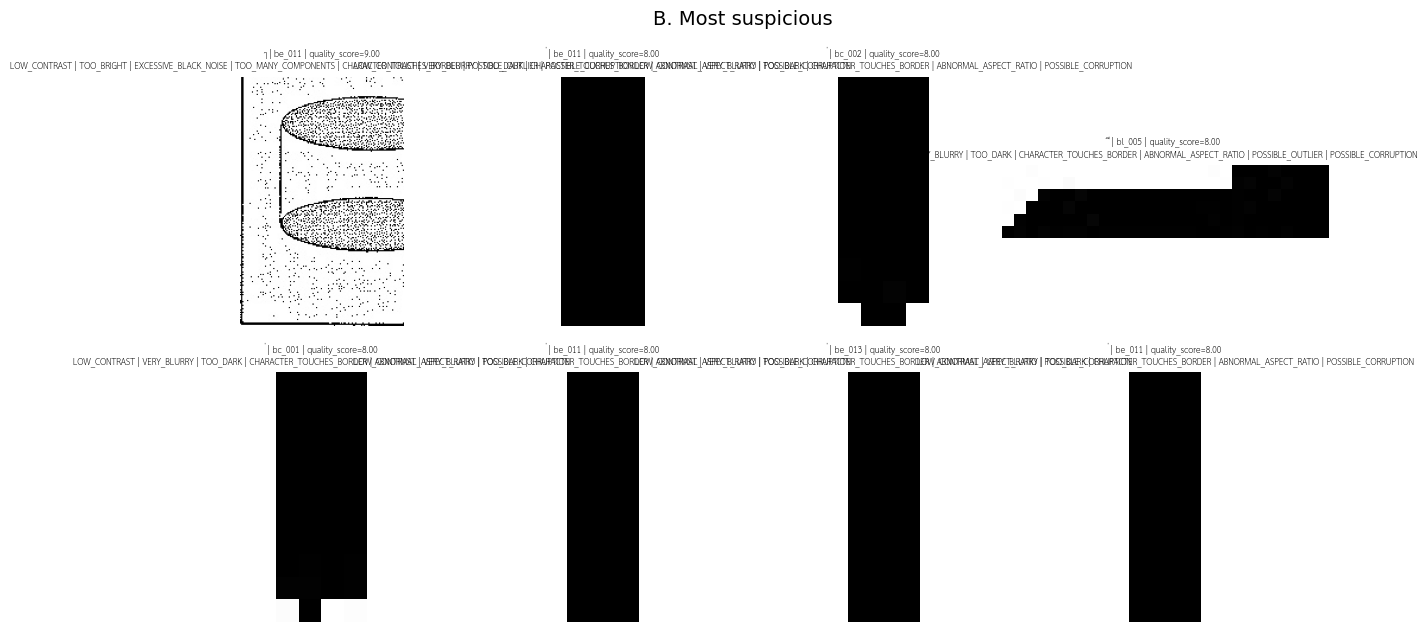

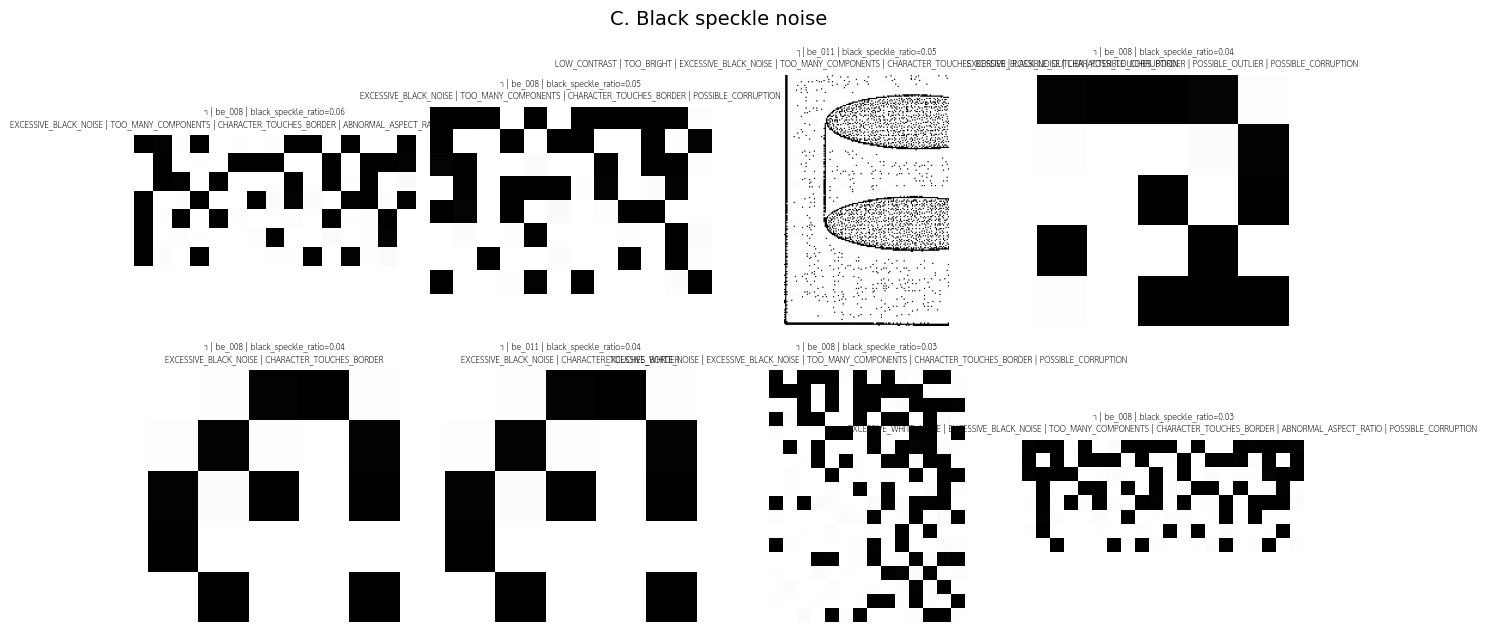

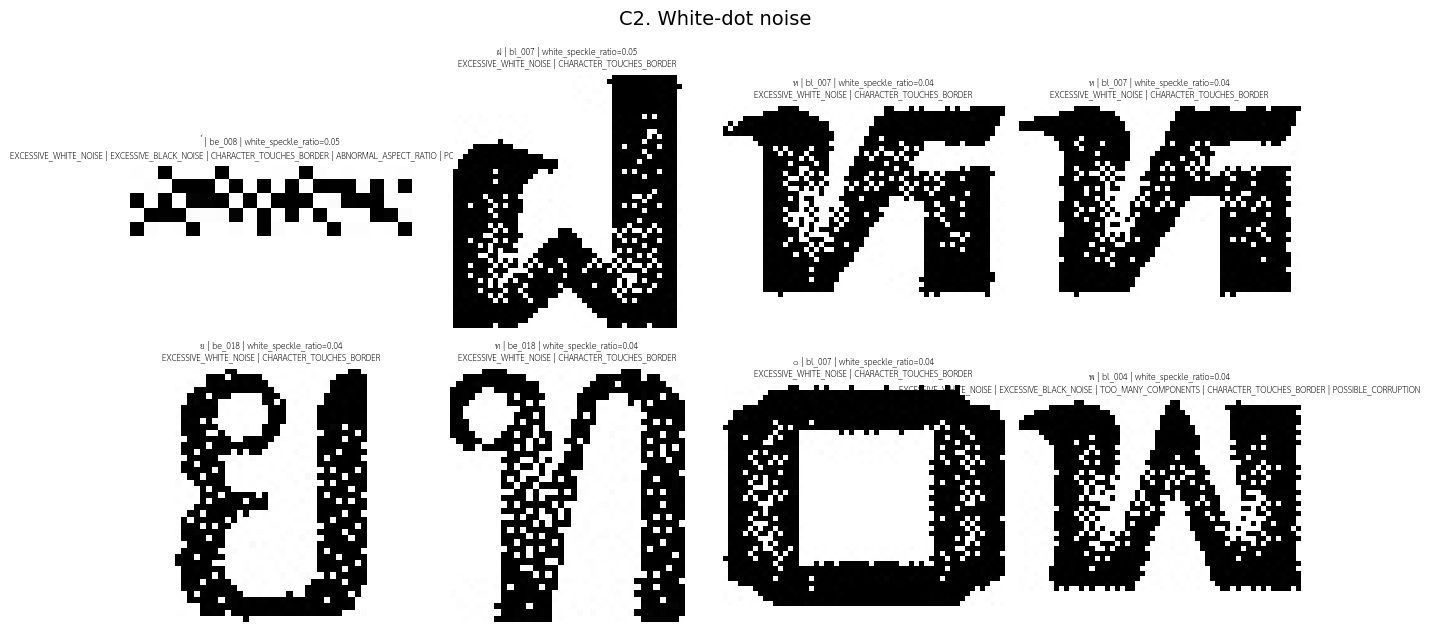

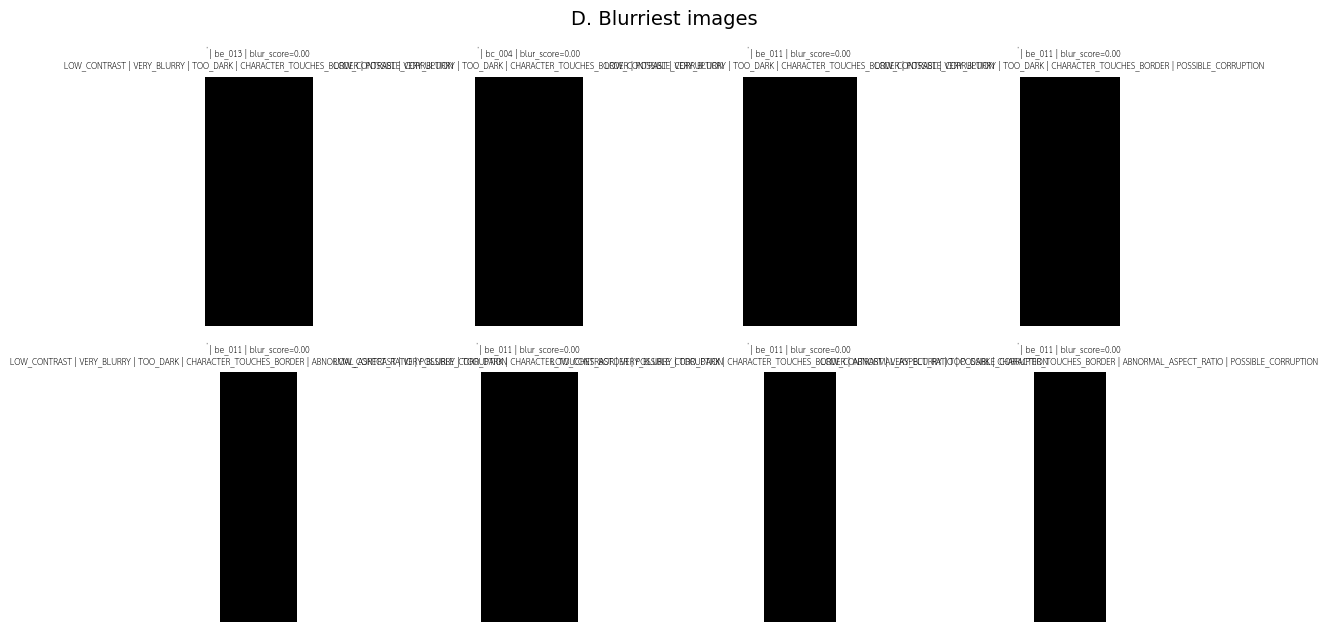

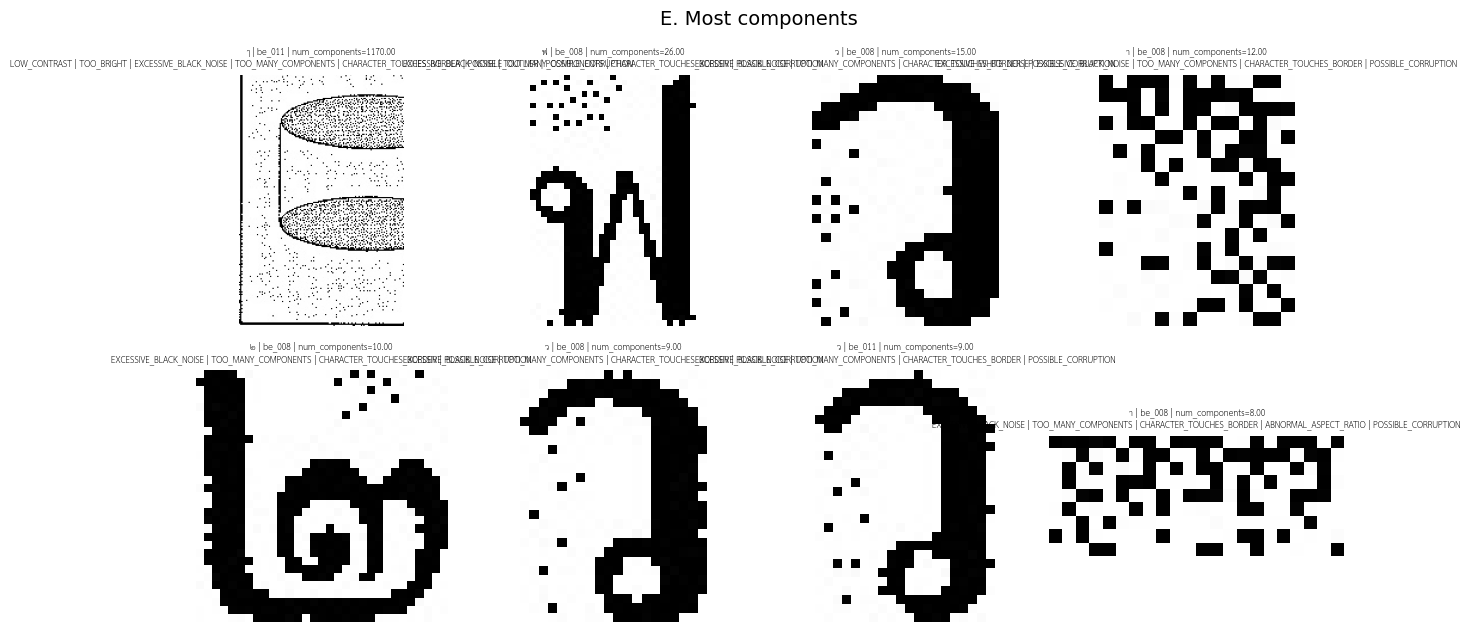

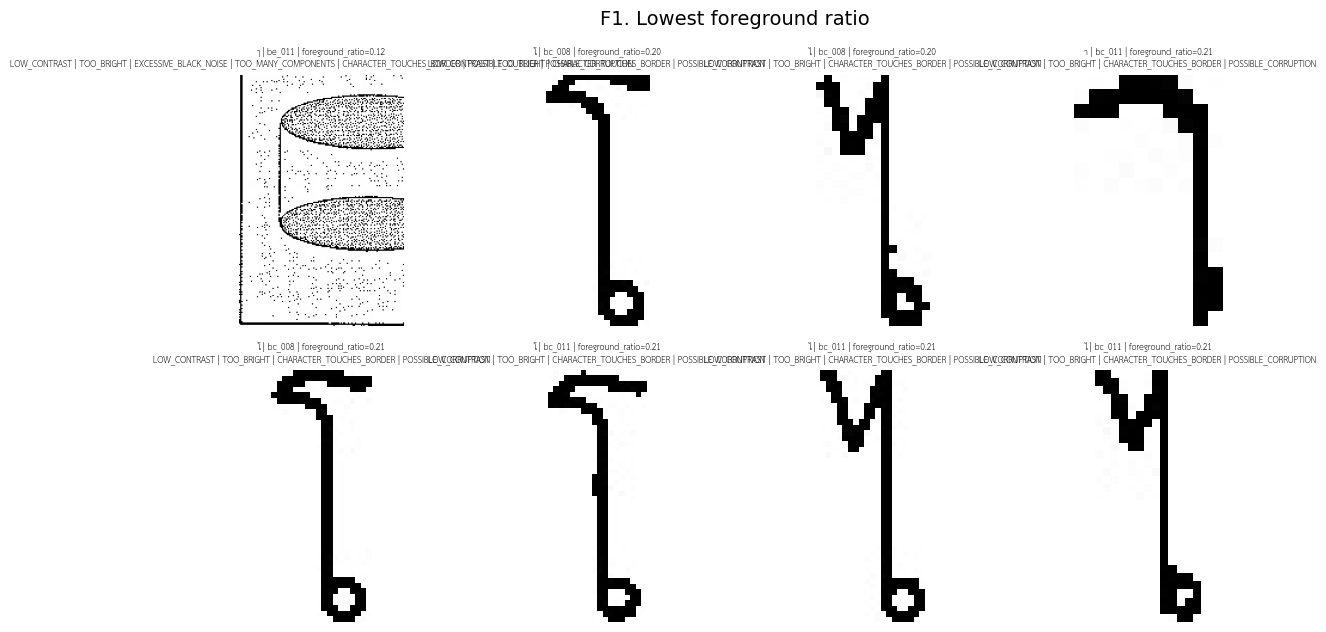

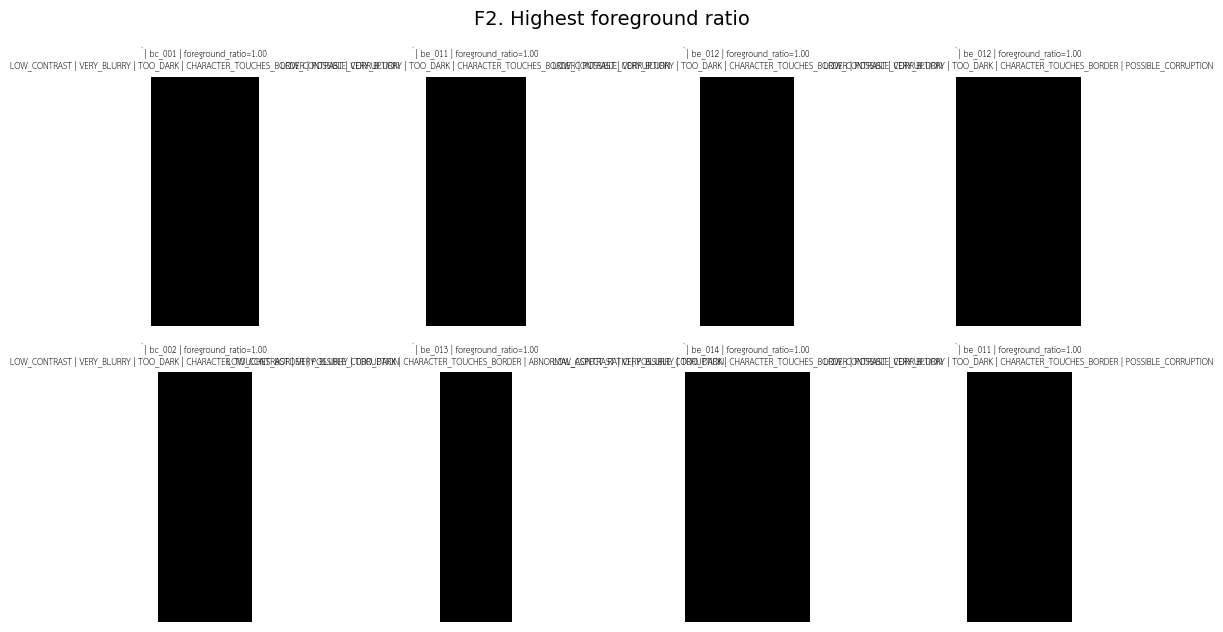

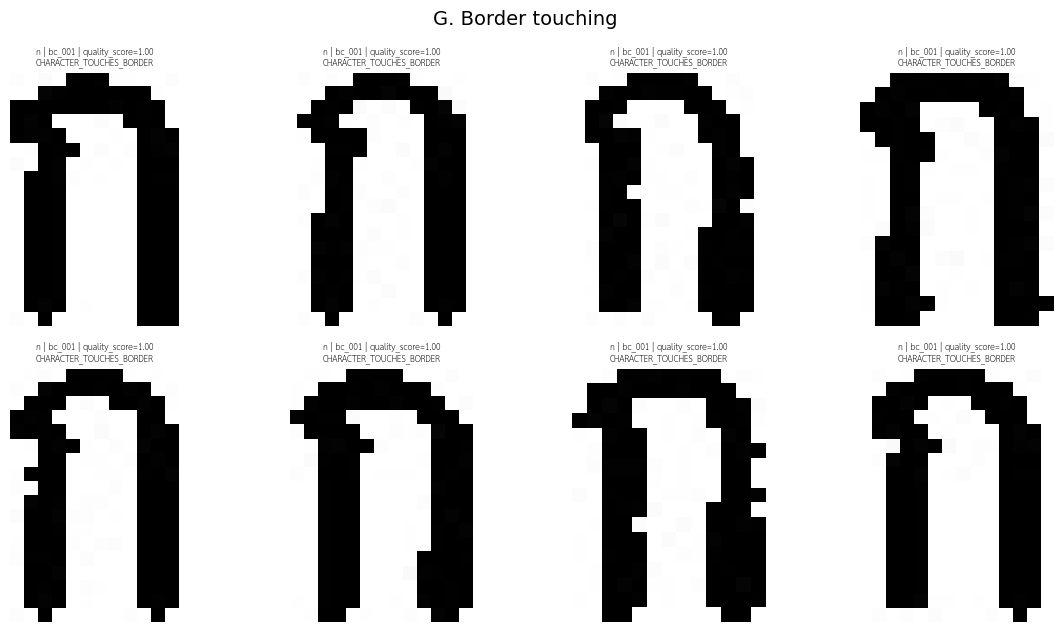

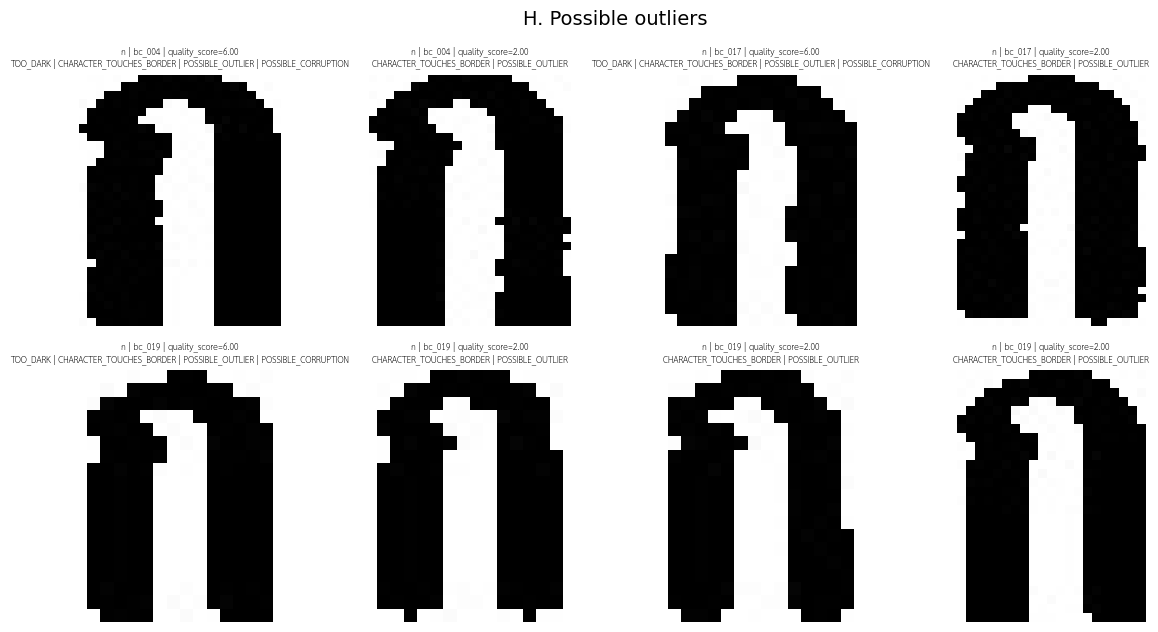

In [18]:
def show_grid(rows, title, score_col='quality_score', limit=8):
    rows = rows.head(limit)
    if rows.empty:
        print(f'{title}: no samples')
        return
    cols = min(4, len(rows))
    fig, axes = plt.subplots(int(np.ceil(len(rows) / cols)), cols,
                             figsize=(3.0 * cols, 3.2 * np.ceil(len(rows) / cols)), squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for ax, row in zip(axes.ravel(), rows.itertuples(index=False)):
        with Image.open(RAW / row.file_path) as image:
            ax.imshow(image.convert('L'), cmap='gray', vmin=0, vmax=255)
        score = getattr(row, score_col, np.nan)
        ax.set_title(f'{row.class_name} | {row.writer_id} | {score_col}={score:.2f}\n{row.quality_flags or "unflagged"}',
                     fontproperties=THAI, fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(SEED)
normal = quality[(quality.quality_flags == '') & quality.read_error.eq('')]
visible = quality[quality.read_error.eq('')]
show_grid(normal.sample(min(8, len(normal)), random_state=SEED), 'A. Random normal samples')
show_grid(visible.sort_values('quality_score', ascending=False), 'B. Most suspicious')
show_grid(visible.sort_values('black_speckle_ratio', ascending=False), 'C. Black speckle noise', 'black_speckle_ratio')
show_grid(visible.sort_values('white_speckle_ratio', ascending=False), 'C2. White-dot noise', 'white_speckle_ratio')
show_grid(visible.sort_values('blur_score'), 'D. Blurriest images', 'blur_score')
show_grid(visible.sort_values('num_components', ascending=False), 'E. Most components', 'num_components')
show_grid(visible.sort_values('foreground_ratio'), 'F1. Lowest foreground ratio', 'foreground_ratio')
show_grid(visible.sort_values('foreground_ratio', ascending=False), 'F2. Highest foreground ratio', 'foreground_ratio')
show_grid(visible[visible.border_touch], 'G. Border touching')
show_grid(visible[visible.quality_flags.str.contains('POSSIBLE_OUTLIER')], 'H. Possible outliers')

## 5. Cleaning & Preprocessing

Compare original, character-centered crop, selective pixel repair, and conservative component cleaning. Every candidate gets visual review before validation experiments. No flags cause automatic deletion.

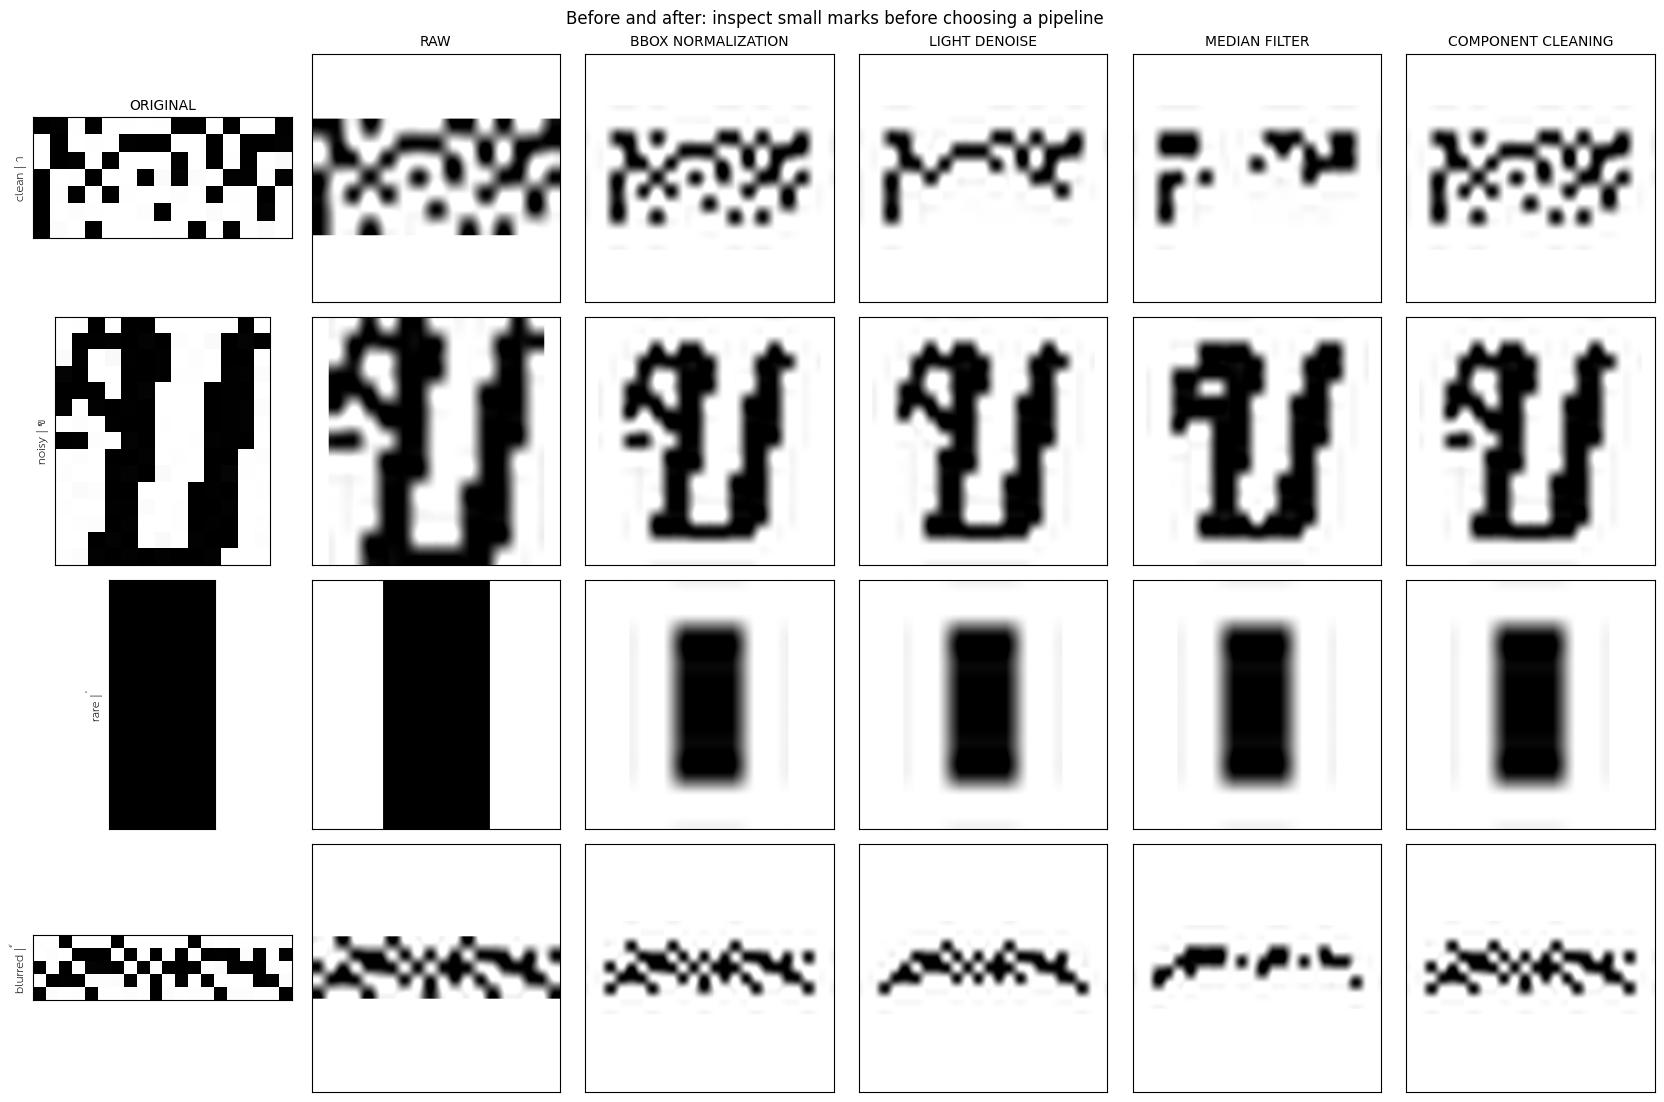

Preprocessing preview complete. Candidate selection follows validation metrics; no images removed.


In [19]:
rare_ids = set(classes.loc[classes.train_n < 20, 'class_idx'])
choices = {
    'clean': normal,
    'noisy': visible.sort_values('black_speckle_ratio', ascending=False),
    'rare': visible[visible.class_idx.isin(rare_ids)],
    'blurred': visible.sort_values('blur_score'),
    'white dots': visible.sort_values('white_speckle_ratio', ascending=False),
}
representatives = [frame.iloc[0] for frame in choices.values() if len(frame)]
modes = ['RAW', 'BBOX_NORMALIZATION', 'LIGHT_DENOISE', 'MEDIAN_FILTER', 'COMPONENT_CLEANING']
fig, axes = plt.subplots(len(representatives), len(modes) + 1,
                         figsize=(2.8 * (len(modes) + 1), 2.8 * len(representatives)), squeeze=False)
for row_i, row in enumerate(representatives):
    with Image.open(RAW / row.file_path) as image:
        original = image.convert('L')
        axes[row_i, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
        for col_i, mode in enumerate(modes, start=1):
            axes[row_i, col_i].imshow(preprocess_candidate(original, IMAGE_SIZE, mode), cmap='gray', vmin=0, vmax=255)
    axes[row_i, 0].set_ylabel(f'{list(choices)[row_i]} | {row.class_name}', fontproperties=THAI)
for ax, name in zip(axes[0], ['ORIGINAL'] + modes): ax.set_title(name.replace('_', ' '), fontsize=10)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Before and after: inspect small marks before choosing a pipeline')
plt.tight_layout()
plt.show()
print('Preprocessing preview complete. Candidate selection follows validation metrics; no images removed.')

## 6. Writer-Level Split

Freeze the effective split for every experiment. The supplied split ID alone is insufficient because training membership changed to remove leakage.

In [20]:
assert train_rows.path.is_unique and val_rows.path.is_unique
assert not set(train_rows.path) & set(val_rows.path)
print('EFFECTIVE SPLIT READY')
print(f'Train {len(train_rows):,} | Validation {len(val_rows):,} | Writer overlap 0 | SHA overlap 0 | Near-duplicate overlap 0')
print(f'Source split ID: {split_run["split_id"]}; experiment cache also hashes exact effective membership.')

EFFECTIVE SPLIT READY
Train 47,823 | Validation 12,032 | Writer overlap 0 | SHA overlap 0 | Near-duplicate overlap 0
Source split ID: 49bb16a21863; experiment cache also hashes exact effective membership.


## 7. Rare-Class Analysis

Classes without validation support remain train-only and cannot receive a measured recall. Compare rare-class recall only where validation contains examples.

In [21]:
counts = effective.groupby(['class_idx', 'split']).size().unstack(fill_value=0).reindex(classes.class_idx, fill_value=0)
rare_table = classes[['class_idx', 'character']].copy()
rare_table['train_n'] = counts['train'].to_numpy()
rare_table['val_n'] = counts['val'].to_numpy()
rare_table['status'] = np.select([rare_table.train_n < 20, rare_table.train_n < 100],
                                  ['critical', 'rare'], default='common')
rare_ids = set(rare_table.loc[rare_table.status != 'common', 'class_idx'])
rare_feasible = rare_table[(rare_table.status != 'common') & (rare_table.val_n > 0)]
rare_infeasible = rare_table[(rare_table.status != 'common') & (rare_table.val_n == 0)]
print('RARE CLASS ANALYSIS')
print(f'Critical Classes       : {(rare_table.status == "critical").sum()}')
print(f'Rare Classes           : {(rare_table.status == "rare").sum()}')
print(f'Validation Feasible    : {len(rare_feasible)}')
print(f'Validation Infeasible  : {len(rare_infeasible)}')
display(rare_table[rare_table.status != 'common'].sort_values('train_n'))

RARE CLASS ANALYSIS
Critical Classes       : 14
Rare Classes           : 16
Validation Feasible    : 19
Validation Infeasible  : 11


,class_idx,character,train_n,val_n,status
2,2,ฃ,0,0,critical
69,69,๗,1,0,critical
12,12,ฑ,1,0,critical
38,38,ฬ,3,0,critical
46,46,ึ,4,0,critical
68,68,๖,8,0,critical
40,40,ฮ,10,0,critical
31,31,ฤ,10,0,critical
66,66,๔,13,0,critical
71,71,๙,13,0,critical


## 8. Augmentation

Light, moderate, strong, and rare-class adaptive affine transforms preserve glyph orientation. Review examples before training; validation never receives augmentation.

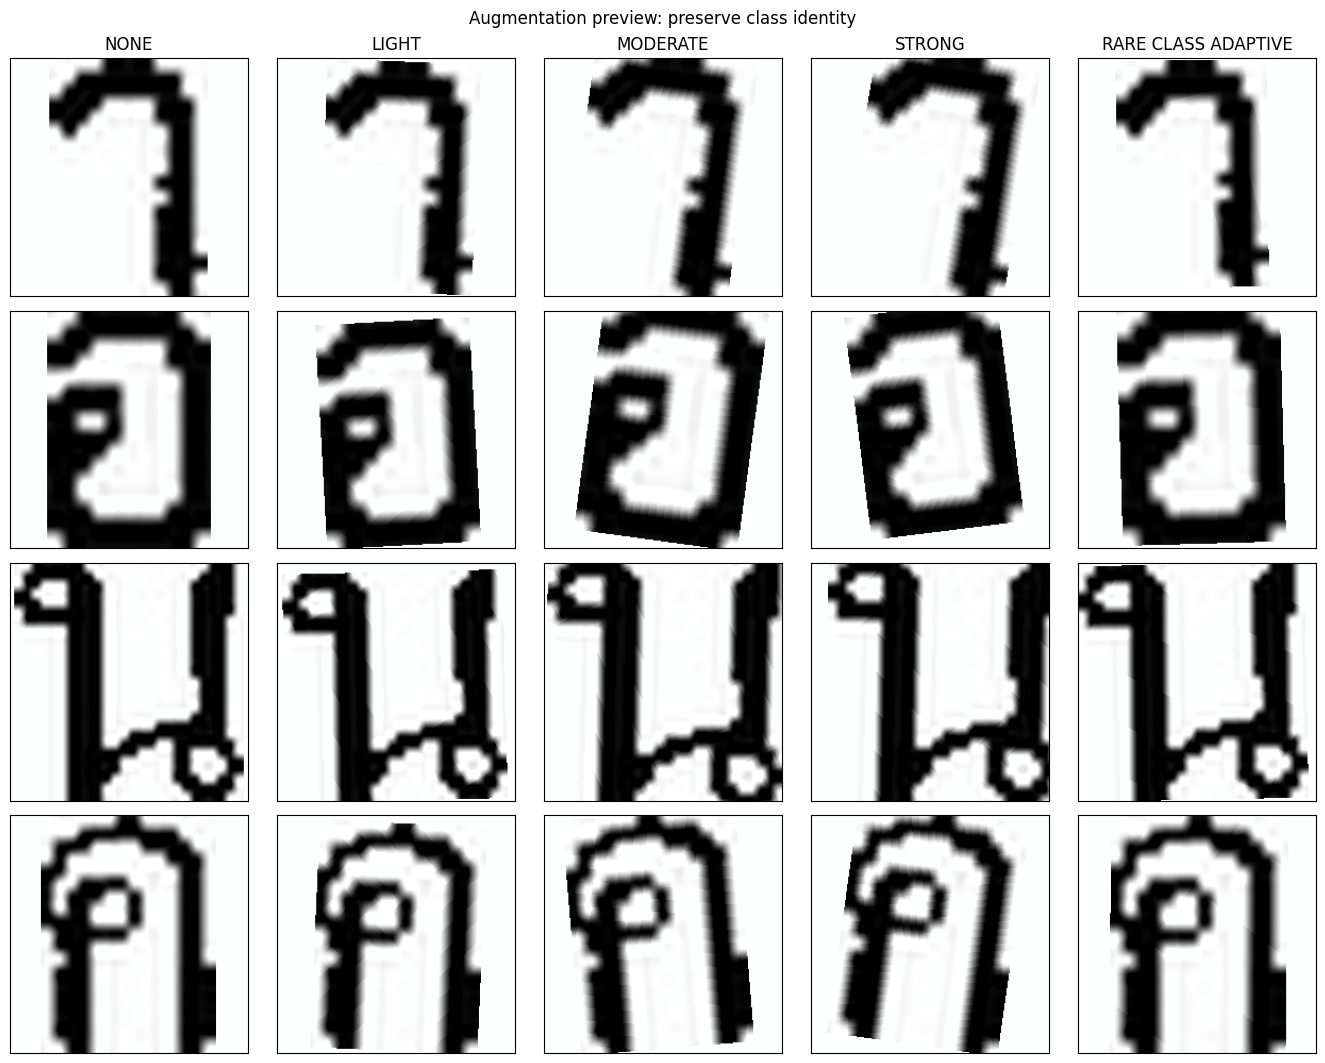

Augmentation candidates previewed; validation inputs remain deterministic.


In [22]:
preview = train_rows.sample(min(4, len(train_rows)), random_state=SEED).copy()
preview['rare_class'] = preview.class_idx.isin(rare_ids)
levels = ['NONE', 'LIGHT', 'MODERATE', 'STRONG', 'RARE_CLASS_ADAPTIVE']
fig, axes = plt.subplots(len(preview), len(levels), figsize=(2.7 * len(levels), 2.7 * len(preview)), squeeze=False)
for j, level in enumerate(levels):
    spec = Experiment(name='preview', phase='preview', augmentation=level, preprocess='RAW', image_size=IMAGE_SIZE)
    dataset = GlyphDataset(preview, RAW, spec, training=level != 'NONE')
    for i in range(len(preview)):
        x, _, _ = dataset[i]
        shown = (x.permute(1, 2, 0).numpy() * np.array([.229, .224, .225]) + np.array([.485, .456, .406])).clip(0, 1)
        axes[i, j].imshow(shown)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
    axes[0, j].set_title(level.replace('_', ' '))
plt.suptitle('Augmentation preview: preserve class identity')
plt.tight_layout()
plt.show()
print('Augmentation candidates previewed; validation inputs remain deterministic.')

## 9. DataLoaders

Decode images lazily after quality inspection. The training loader reads only secure training rows; weighted sampling is tested as a separate phase.

In [23]:
probe = train_rows.head(2).copy()
probe['rare_class'] = probe.class_idx.isin(rare_ids)
probe_set = GlyphDataset(probe, RAW, Experiment(name='probe', phase='setup'), training=False)
probe_loader = DataLoader(probe_set, batch_size=2, num_workers=0)
batch_x, batch_y, batch_paths = next(iter(probe_loader))
print('DATALOADER CHECK')
print(f'Batch shape: {tuple(batch_x.shape)} | Labels: {batch_y.tolist()}')
print(f'Train rows: {len(train_rows):,} | Validation rows: {len(val_rows):,}')
print(f'Input range after ImageNet normalization: {batch_x.min():.2f} to {batch_x.max():.2f}')

DATALOADER CHECK
Batch shape: (2, 3, 224, 224) | Labels: [0, 0]
Train rows: 47,823 | Validation rows: 12,032
Input range after ImageNet normalization: -2.12 to 2.64


## 10. Model

ImageNet pretrained ResNet50, EfficientNetV2-S, and ConvNeXt-Tiny share the same 72-class head. Unreviewed label identities remain visible as a limitation; structural and encoding checks are complete.

In [24]:
unreviewed = audit_labels[~audit_labels.reviewed]
print('LABEL REVIEW STATUS')
print(f'Structural labels: 72 unique / 72 expected')
print(f'TIS-620 mappings: {audit_labels.tis620_matches.sum()} / 72')
print(f'Visually confirmed labels: {72 - len(unreviewed)} / 72')
if len(unreviewed):
    print('Visual label review remains pending; scores use the current configured mapping.')
    display(unreviewed[['class_idx', 'folder', 'label', 'unicode_codepoints', 'confidence', 'note']].head(12))

model_probe = build_backbone('efficientnet_v2_s', 72)
print('MODEL SETUP')
print('Architecture       : EfficientNetV2-S')
print('Pretrained         : ImageNet')
print('Input Size         : 224 × 224')
print('Output Classes     : 72')
print(f'Trainable Params    : {sum(p.numel() for p in model_probe.parameters() if p.requires_grad):,}')
print(f'Frozen Params       : {sum(p.numel() for p in model_probe.parameters() if not p.requires_grad):,}')
del model_probe

LABEL REVIEW STATUS
Structural labels: 72 unique / 72 expected
TIS-620 mappings: 72 / 72
Visually confirmed labels: 0 / 72
Visual label review remains pending; scores use the current configured mapping.


,class_idx,folder,label,unicode_codepoints,confidence,note
0,0,161,ก,U+0E01,,hypothesis: TIS-620 0xA1 -> ko kai
1,1,162,ข,U+0E02,,hypothesis: TIS-620 0xA2 -> kho khai
2,2,163,ฃ,U+0E03,,hypothesis: TIS-620 0xA3 -> kho khuat
3,3,164,ค,U+0E04,,hypothesis: TIS-620 0xA4 -> kho khwai
4,4,167,ง,U+0E07,,hypothesis: TIS-620 0xA7 -> ngo ngu
5,5,168,จ,U+0E08,,hypothesis: TIS-620 0xA8 -> cho chan
6,6,169,ฉ,U+0E09,,hypothesis: TIS-620 0xA9 -> cho ching
7,7,170,ช,U+0E0A,,hypothesis: TIS-620 0xAA -> cho chang
8,8,171,ซ,U+0E0B,,hypothesis: TIS-620 0xAB -> so so
9,9,173,ญ,U+0E0D,,hypothesis: TIS-620 0xAD -> yo ying


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /Users/iam.pxk/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 46.6MB/s]

MODEL SETUP
Architecture       : EfficientNetV2-S
Pretrained         : ImageNet
Input Size         : 224 × 224
Output Classes     : 72
Trainable Params    : 20,269,720
Frozen Params       : 0


## 11. Training Engine

Each epoch prints loss, accuracy, macro F1, learning rate, and checkpoint status. Cache files contain metrics, history, predictions, and best weights.

In [25]:
def execute(spec):
    run_dir, result = run_experiment(spec, effective, RAW, RUN_ROOT, 72, rare_ids, workers=WORKERS)
    return {'phase': spec.phase, 'experiment': spec.name, 'run_dir': str(run_dir), **result}

def show_board(rows, title):
    board = pd.DataFrame(rows).sort_values(['macro_f1', 'rare_recall'], ascending=False)
    print(title)
    display(board[['experiment', 'model', 'preprocess', 'augmentation', 'sampler', 'loss',
                   'val_accuracy', 'macro_f1', 'weighted_f1', 'rare_recall', 'best_epoch', 'training_seconds']].round(4))
    return board

print('TRAINING ENGINE READY')
print(f'Run root: {RUN_ROOT}')
print('Ranking: macro F1, then rare-class recall; all phases use the same effective split.')

TRAINING ENGINE READY
Run root: /Users/iam.pxk/Desktop/thai-char-cnn/runs/quality_cv
Ranking: macro F1, then rare-class recall; all phases use the same effective split.


## 12. Experiments

Phase A chooses preprocessing first. Phases B, C, and D then change one axis at a time. The baseline is repeated in each comparison for a direct reference.

In [ ]:
data_specs = [
    Experiment('D01', 'data', preprocess='RAW', epochs=SCREEN_EPOCHS),
    Experiment('D02', 'data', preprocess='BBOX_NORMALIZATION', epochs=SCREEN_EPOCHS),
    Experiment('D03', 'data', preprocess='LIGHT_DENOISE', epochs=SCREEN_EPOCHS),
    Experiment('D04', 'data', preprocess='COMPONENT_CLEANING', epochs=SCREEN_EPOCHS),
    Experiment('D05', 'data', preprocess='MEDIAN_FILTER', epochs=SCREEN_EPOCHS),
]
data_results = [execute(spec) for spec in data_specs]
data_board = show_board(data_results, 'PHASE A — DATA QUALITY')
fig, ax = plt.subplots(figsize=(8, 3.6))
ordered = pd.DataFrame(data_results).sort_values('experiment')
ax.bar(ordered.experiment, ordered.macro_f1, color='#4C72B0')
ax.set(title='Did preprocessing improve validation macro F1?', xlabel='Preprocessing candidate', ylabel='Macro F1', ylim=(0, 1))
ax.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.show()
raw_result = data_board[data_board.experiment == 'D01'].iloc[0]
eligible = data_board[(data_board.experiment == 'D01') |
                      ((data_board.macro_f1 >= raw_result.macro_f1 + .005) &
                       (pd.isna(raw_result.rare_recall) |
                        (data_board.rare_recall >= raw_result.rare_recall - .02)))]
best_preprocess = eligible.iloc[0].preprocess
print(f'Selected preprocessing: {best_preprocess}')
print('Safety rule: require at least +0.005 macro F1 over RAW and no more than -0.02 rare recall; otherwise retain RAW.')

D01 1/5:   0%|          | 0/1495 [00:00<?, ?it/s]

D01 epoch 01/5 | train loss 0.2379, acc 94.22% | val loss 0.0996, acc 97.27%, macro F1 0.9566 | lr 0.000300 | checkpoint SAVED


D01 2/5:   0%|          | 0/1495 [00:00<?, ?it/s]

D01 epoch 02/5 | train loss 0.0946, acc 97.52% | val loss 0.0983, acc 97.29%, macro F1 0.9637 | lr 0.000300 | checkpoint SAVED


D01 3/5:   0%|          | 0/1495 [00:00<?, ?it/s]

...

D02 1/5:   0%|          | 0/1495 [00:00<?, ?it/s]

D02 epoch 01/5 | train loss 0.2367, acc 94.24% | val loss 0.1005, acc 96.93%, macro F1 0.9290 | lr 0.000300 | checkpoint SAVED


D02 2/5:   0%|          | 0/1495 [00:00<?, ?it/s]

D02 epoch 02/5 | train loss 0.0953, acc 97.44% | val loss 0.1154, acc 96.97%, macro F1 0.9650 | lr 0.000300 | checkpoint SAVED


D02 3/5:   0%|          | 0/1495 [00:00<?, ?it/s]

In [ ]:
augment_specs = [Experiment(f'A0{i}', 'augmentation', preprocess=best_preprocess,
                            augmentation=level, epochs=SCREEN_EPOCHS)
                 for i, level in enumerate(['LIGHT', 'MODERATE', 'STRONG', 'RARE_CLASS_ADAPTIVE'], 1)]
augment_results = [execute(spec) for spec in augment_specs]
augment_board = show_board(augment_results, 'PHASE B — AUGMENTATION')
best_augmentation = augment_board.iloc[0].augmentation
print(f'Selected augmentation: {best_augmentation}')

In [ ]:
model_specs = [Experiment(f'M0{i}', 'model', preprocess=best_preprocess,
                          augmentation=best_augmentation, model=name, epochs=SCREEN_EPOCHS)
               for i, name in enumerate(['resnet50', 'efficientnet_v2_s', 'convnext_tiny'], 1)]
model_results = [execute(spec) for spec in model_specs]
model_board = show_board(model_results, 'PHASE C — MODEL')
best_model = model_board.iloc[0].model
print(f'Selected model: {best_model}; runner-up: {model_board.iloc[1].model}')

In [ ]:
imbalance_options = [('standard', 'ce'), ('weighted', 'ce'),
                     ('standard', 'weighted_ce'), ('weighted', 'label_smoothing')]
imbalance_specs = [Experiment(f'I0{i}', 'imbalance', preprocess=best_preprocess,
                              augmentation=best_augmentation, model=best_model,
                              sampler=sampler, loss=loss, epochs=SCREEN_EPOCHS)
                   for i, (sampler, loss) in enumerate(imbalance_options, 1)]
imbalance_results = [execute(spec) for spec in imbalance_specs]
imbalance_board = show_board(imbalance_results, 'PHASE D — IMBALANCE AND LOSS')
best_sampler, best_loss = imbalance_board.iloc[0][['sampler', 'loss']]
print(f'Selected sampler: {best_sampler} | loss: {best_loss}')

## 13. Fine-Tuning

Run two-stage fine-tuning with the best prior settings and an alternative learning rate. Optional MixUp and TTA come after this comparison.

In [ ]:
final_common = dict(preprocess=best_preprocess, augmentation=best_augmentation,
                    model=best_model, sampler=best_sampler, loss=best_loss,
                    epochs=FINAL_EPOCHS, two_stage=True)
fine_specs = [Experiment('F01', 'fine_tune', **final_common),
              Experiment('F02', 'fine_tune', lr=1e-4, **final_common)]
fine_results = [execute(spec) for spec in fine_specs]
fine_board = show_board(fine_results, 'PHASE E — FINAL FINE-TUNING')
best_final = fine_board.iloc[0]
print(f'Best run: {best_final.experiment} | {best_final.run_dir}')
from dataclasses import replace
selected_spec = next(spec for spec in fine_specs if spec.name == best_final.experiment)
replicates = [best_final.to_dict()]
for repeat_seed in (137, 271):
    replicates.append(execute(replace(selected_spec, name=f'{selected_spec.name}_S{repeat_seed}', seed=repeat_seed)))
replicate_table = pd.DataFrame(replicates)
print('SELECTED CONFIGURATION — THREE SEEDS')
display(replicate_table[['experiment', 'seed', 'val_accuracy', 'macro_f1', 'rare_recall']].round(4))
print(f'Macro F1 mean ± SD: {replicate_table.macro_f1.mean():.4f} ± {replicate_table.macro_f1.std():.4f}')
RUN_OPTIONAL_MIXUP = False
if RUN_OPTIONAL_MIXUP:
    mixup_result = execute(Experiment('F03', 'optional', mixup=True, **final_common))
    display(pd.DataFrame([mixup_result])[['experiment', 'val_accuracy', 'macro_f1', 'rare_recall']].round(4))
else:
    print('F03 MixUp: skipped. Set RUN_OPTIONAL_MIXUP=True to compare.')

## 14. Evaluation

Read predictions from the selected checkpoint. Scores describe the held-out filename groups only. TTA remains optional and requires separate validation comparison.

In [ ]:
best_dir = Path(best_final.run_dir)
predictions = pd.read_csv(best_dir / 'val_predictions.csv')
from thai_char_cnn.metrics import confusion, per_class, top_confused
cm = confusion(predictions.true_idx.to_numpy(), predictions.pred_idx.to_numpy(), 72)
per_class_table = per_class(cm).merge(classes[['class_idx', 'character']], on='class_idx')
print('BEST VALIDATION RESULT')
for key in ['experiment', 'model', 'preprocess', 'augmentation', 'sampler', 'loss',
            'best_epoch', 'val_accuracy', 'macro_f1', 'weighted_f1', 'rare_recall']:
    print(f'{key:18}: {best_final[key]}')
display(per_class_table.sort_values('f1').head(15).round(3))
fig, ax = plt.subplots(figsize=(14, 4))
shown = per_class_table[per_class_table.support > 0].sort_values('f1')
ax.bar(range(len(shown)), shown.f1, color='#4C72B0')
ax.set_xticks(range(len(shown)), shown.character, fontproperties=THAI)
ax.set(title='Which classes have lowest validation F1?', ylabel='F1', ylim=(0, 1.05))
ax.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.show()
RUN_OPTIONAL_TTA = False
if RUN_OPTIONAL_TTA:
    import torchvision.transforms.functional as TF
    tta_model = build_backbone(best_final.model, 72)
    checkpoint = torch.load(best_dir / 'model.pt', map_location='cpu', weights_only=True)
    tta_model.load_state_dict(checkpoint['state_dict'])
    tta_model = tta_model.to(DEVICE).eval()
    tta_frame = val_rows.copy()
    tta_frame['rare_class'] = tta_frame.class_idx.isin(rare_ids)
    tta_set = GlyphDataset(tta_frame, RAW, Experiment('F04', 'optional', preprocess=best_preprocess), training=False)
    tta_loader = DataLoader(tta_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)
    white_fill = [(1 - mean) / std for mean, std in zip((.485, .456, .406), (.229, .224, .225))]
    tta_predictions = []
    with torch.no_grad():
        for x, _, _ in tta_loader:
            x = x.to(DEVICE)
            logits = [tta_model(x)]
            for angle in (-3, 3):
                logits.append(tta_model(TF.rotate(x, angle, fill=white_fill)))
            tta_predictions.extend(torch.stack(logits).softmax(-1).mean(0).argmax(1).cpu().numpy().tolist())
    tta_cm = confusion(predictions.true_idx.to_numpy(), np.asarray(tta_predictions), 72)
    print('F04 OPTIONAL TTA')
    print(f'Base macro F1: {best_final.macro_f1:.4f} | TTA macro F1: {macro_f1(tta_cm):.4f}')
    print(f'Base accuracy: {best_final.val_accuracy:.4f} | TTA accuracy: {np.trace(tta_cm) / tta_cm.sum():.4f}')
    del tta_model
else:
    print('F04 TTA: skipped. Set RUN_OPTIONAL_TTA=True to compare the selected checkpoint.')

## 15. Error Analysis

Review high-frequency confusions, confident mistakes, and class-relative embedding outliers. Embedding distance is a review signal, never an automatic relabeling rule.

In [ ]:
confused = top_confused(cm, 15)
names = classes.set_index('class_idx').character
confused['true_label'] = confused.true_idx.map(names)
confused['predicted_label'] = confused.pred_idx.map(names)
print('MOST CONFUSED PAIRS')
display(confused[['true_label', 'predicted_label', 'count', 'share_of_true']].round(3))
errors = predictions[predictions.true_idx != predictions.pred_idx].copy()
errors = errors.merge(quality[['file_path', 'quality_flags', 'quality_score']],
                      left_on='path', right_on='file_path', how='left')
print(f'Validation errors: {len(errors):,} / {len(predictions):,}')
display(errors.sort_values('p_pred', ascending=False).head(20)[
    ['path', 'writer_id', 'true_idx', 'pred_idx', 'p_pred', 'p_true', 'quality_flags', 'quality_score']].round(3))
error_grid = errors.sort_values('p_pred', ascending=False).head(12).copy()
error_grid['class_name'] = error_grid.true_idx.map(names)
show_grid(error_grid, 'Most confident validation mistakes', 'p_pred', 12)
quality_error_grid = errors.sort_values('quality_score', ascending=False).head(12).copy()
quality_error_grid['class_name'] = quality_error_grid.true_idx.map(names)
show_grid(quality_error_grid, 'Validation errors with quality concerns', 'quality_score', 12)

In [ ]:
RUN_EMBEDDING_AUDIT = True
if RUN_EMBEDDING_AUDIT:
    from thai_char_cnn.cv_experiments import build_backbone
    import torch.nn.functional as F
    backbone = build_backbone('resnet50', 72)
    backbone.fc = torch.nn.Identity()
    backbone = backbone.to(DEVICE).eval()
    feature_rows = effective.copy()
    feature_rows['rare_class'] = feature_rows.class_idx.isin(rare_ids)
    feature_set = GlyphDataset(feature_rows, RAW, Experiment('embedding', 'audit'), training=False)
    feature_loader = DataLoader(feature_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)
    vectors = []
    with torch.no_grad():
        for x, _, _ in feature_loader:
            vectors.append(F.normalize(backbone(x.to(DEVICE)), dim=1).cpu().numpy())
    vectors = np.concatenate(vectors)
    centers = np.stack([F.normalize(torch.from_numpy(vectors[feature_rows.class_idx.to_numpy() == i].mean(0)), dim=0).numpy()
                        for i in range(72)])
    distances = 1 - (vectors * centers[feature_rows.class_idx.to_numpy()]).sum(1)
    embedding_outliers = feature_rows[['path', 'class_idx', 'writer_id']].copy()
    embedding_outliers['distance_to_class_center'] = distances
    embedding_outliers['possible_outlier'] = embedding_outliers.groupby('class_idx').distance_to_class_center.transform(
        lambda scores: scores >= scores.quantile(.99))
    embedding_outliers = embedding_outliers.merge(quality[['file_path', 'class_name', 'quality_flags']],
                                                left_on='path', right_on='file_path', how='left')
    print('CLASS-RELATIVE EMBEDDING OUTLIERS')
    display(embedding_outliers.nlargest(20, 'distance_to_class_center')[
        ['path', 'class_name', 'writer_id', 'distance_to_class_center', 'quality_flags']].round(3))
    show_grid(embedding_outliers.nlargest(12, 'distance_to_class_center'),
              'Embedding outliers for manual inspection', 'distance_to_class_center', 12)
    del backbone
else:
    print('Embedding audit skipped; set RUN_EMBEDDING_AUDIT=True to run pretrained feature review.')

## 16. Final Summary

Report measured quality findings and actual processing counts. Candidate preprocessing is applied lazily at read time. No quality flag silently removes an image.

In [ ]:
flag = quality.quality_flags.astype(str)
cleaned_count = count_cleaned_images(effective.path.tolist(), RAW, best_preprocess)
print('DATA QUALITY REPORT')
for label, number in [
    ('Total images', len(quality)), ('Clean / Unflagged', flag.eq('').sum()),
    ('Flagged', flag.ne('').sum()), ('Potential corruption', flag.str.contains('POSSIBLE_CORRUPTION').sum()),
    ('Potential outliers', flag.str.contains('POSSIBLE_OUTLIER').sum()),
    ('Embedding outliers', int(embedding_outliers.possible_outlier.sum()) if 'embedding_outliers' in globals() else 0),
    ('White / Speckle noise', flag.str.contains('EXCESSIVE_WHITE_NOISE|EXCESSIVE_BLACK_NOISE').sum()),
    ('Blur', flag.str.contains('VERY_BLURRY').sum()),
    ('Border problems', flag.str.contains('CHARACTER_TOUCHES_BORDER').sum()),
    ('Extreme foreground ratio', flag.str.contains('POSSIBLE_EMPTY|CHARACTER_TOO_SMALL').sum()),
    ('Removed Images', 0),
    ('Cleaned Images', cleaned_count),
    ('Unmodified Images', len(effective) - cleaned_count),
]: print(f'{label:25}: {number:,}')
print(f'Excluded from training to prevent leakage: {split_info["writer_conflict_removed"] + split_info["exact_twin_removed"] + split_info["near_twin_removed"]:,}')
print(f'Unavailable raw images excluded from model data: {len(missing_files):,}')
print('Unmodified counts refer to source-resolution pixel cleaning; crop and resize are reported separately.')
print(f'Best preprocessing: {best_preprocess}')
print(f'Best model: {best_final.model} | accuracy {best_final.val_accuracy:.4f} | macro F1 {best_final.macro_f1:.4f}')
print(f'Final checkpoint: {best_dir / "model.pt"}')